# 两个平面 2R 手指抓取圆：SymPy → SLSQP → MuJoCo
未知量为 z = [q00, q01, q10, q11, x, y]。第二关节角为相对角；角度单位 rad，长度单位 m。
**r 是圆的半径，二维连杆视为零厚度线段。** 三维显示粗细不进入二维运动学或优化公式。
本例参考 grasping_synthesis.py 中的垂足、接触、摩擦锥构造，不依赖原项目。
几何条件不能唯一确定六个未知量，下面以 cost 选择一组局部最优解，不声称穷举所有解。
依赖：numpy sympy scipy matplotlib mujoco IPython；可在 notebook 中用 %pip install 安装。

In [1]:
from pathlib import Path
import time
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display

## 1. 符号正运动学
从一个向量开始：长度为 $l$、与 x 轴夹角为 $\theta$ 的杆，位移为
$$l\,e(\theta)=l\begin{bmatrix}\cos\theta\\\sin\theta\end{bmatrix}.$$
因为第二个关节角是**相对第一根杆**的角，AB 的绝对方向是 $q_{00}+q_{01}$，不是 $q_{01}$。
$$A=l_{00}e(q_{00}),\quad B=A+l_{01}e(q_{00}+q_{01}),$$
$$C=l_{10}e(q_{10}),\quad D=C+l_{11}e(q_{10}+q_{11}).$$
两个手指都以 O 为基座，逆时针为正。课堂检查：令四个角都为零，四根杆是否都指向 x 正方向？
优化变量记作 $\boldsymbol z=[q_{00},q_{01},q_{10},q_{11},x,y]^T$，避免与空间高度 z 混淆。

In [2]:
q00, q01, q10, q11, x, y = sp.symbols('q_00 q_01 q_10 q_11 x y', real=True)
l00, l01, l10, l11, r = sp.symbols('l_00 l_01 l_10 l_11 r', positive=True)
z = sp.Matrix([q00, q01, q10, q11, x, y])
e = lambda a: sp.Matrix([sp.cos(a), sp.sin(a)])
O = sp.zeros(2, 1)
A = l00 * e(q00)
B = A + l01 * e(q00 + q01)
C = l10 * e(q10)
D = C + l11 * e(q10 + q11)
M = sp.Matrix([x, y])
for name, point in [('A', A), ('B', B), ('C', C), ('D', D)]:
    print(name)
    display(point)

A


Matrix([
[l_00*cos(q_00)],
[l_00*sin(q_00)]])

B


Matrix([
[l_00*cos(q_00) + l_01*cos(q_00 + q_01)],
[l_00*sin(q_00) + l_01*sin(q_00 + q_01)]])

C


Matrix([
[l_10*cos(q_10)],
[l_10*sin(q_10)]])

D


Matrix([
[l_10*cos(q_10) + l_11*cos(q_10 + q_11)],
[l_10*sin(q_10) + l_11*sin(q_10 + q_11)]])

## 2. 垂足与接触点
在 AB 的延长线上写一个点 $N_1=A+t_1(B-A)$。垂足满足
$$(M-N_1)^T(B-A)=0.$$
将 $N_1$ 代入并移项，就得到投影公式：
$$t_1=\frac{(M-A)^T(B-A)}{\|B-A\|^2},\qquad N_1=A+t_1(B-A).$$
$t_1=0$ 是 A，$t_1=1$ 是 B；$0<t_1<1$ 才是杆中段接触。第二指把 A、B 换成 C、D。
令 $v_i=M-N_i$。零厚度线段相切要求 $\|v_i\|=r$。
令 $d_i=\|v_i\|$，沿投影方向定义内法向与圆面候选接触点：
$$n_i=\frac{v_i}{d_i},\qquad P_i=M-rn_i.$$
**相切时 P=N，接触点就是垂足。** 尚未相切时，N 在线段延长线上，候选点 P 在圆面上。
未接触时按实际距离 $d_i$ 归一化，不能用 r 代替。
令 $\theta_1=q_{00}+q_{01}$，单位切向量 $u_1=(\cos\theta_1,\sin\theta_1)^T$，
单位法向量 $h_1=(-\sin\theta_1,\cos\theta_1)^T$，公式可简化为
$$t_1=\frac{x\cos\theta_1+y\sin\theta_1-l_{00}\cos q_{01}}{l_{01}},\quad
s_1=(M-A)^Th_1,\quad N_1=M-s_1h_1,\quad d_1=|s_1|.$$
第二指同理。这样无需把长向量表达式反复展开。

In [3]:
theta1, theta2 = q00+q01, q10+q11
h1 = sp.Matrix([-sp.sin(theta1),sp.cos(theta1)])
h2 = sp.Matrix([-sp.sin(theta2),sp.cos(theta2)])
t1 = (x*sp.cos(theta1)+y*sp.sin(theta1)-l00*sp.cos(q01))/l01
t2 = (x*sp.cos(theta2)+y*sp.sin(theta2)-l10*sp.cos(q11))/l11
# 二维单位法向的投影可把距离化简为 |s_i|，避免打印巨大的展开表达式。
s1 = l00*sp.sin(q01)-x*sp.sin(q00+q01)+y*sp.cos(q00+q01)
s2 = l10*sp.sin(q11)-x*sp.sin(q10+q11)+y*sp.cos(q10+q11)
d1, d2 = sp.Abs(s1), sp.Abs(s2)
v1, v2 = s1*h1, s2*h2
N1, N2 = M-v1, M-v2
# 1e-12 m 的保护只用于归一化，防止不可行迭代点 d=0 时除零；cost 用精确距离。
n1 = v1/sp.sqrt(s1**2+sp.Float(1e-24))
n2 = v2/sp.sqrt(s2**2+sp.Float(1e-24))
P1, P2 = M-r*n1, M-r*n2

## 3. 参数与 cost function
默认 l=[0.12,0.10,0.12,0.10]，r=0.035。
定义线段到圆面的间隙 $e_i=d_i-r$：正值表示尚未接触，负值表示穿透。
$$\boxed{J=(|s_1|-r)^2+(|s_2|-r)^2=e_1^2+e_2^2.}$$
**约束要求不穿透，cost 驱动两侧间隙趋于零。** 不再添加相切等式，也不再使用 M_target 或 q_ref。
为改善数值尺度，实际送入 SLSQP 的目标为 $\widetilde J=J/r^2$，这是乘正常数，不改变最优解。
以下同时打印有量纲的 J（m²）、符号 Jacobian 和归一化目标的关系。
利用单位法向投影，$d_1=|s_1|$，其中
$$s_1=l_{00}\sin q_{01}-x\sin(q_{00}+q_{01})+y\cos(q_{00}+q_{01}).$$
第二指同理。Jacobian 是一个行向量（标量目标的梯度转置）：
$$\frac{\partial J}{\partial z_j}=2\sum_{i=1}^2(d_i-r)\frac{\partial d_i}{\partial z_j},\qquad
\frac{\partial d_i}{\partial z_j}=\operatorname{sign}(s_i)\frac{\partial s_i}{\partial z_j}.$$
距离在 s=0 处不可微；这代表圆心落在杆中心线上，是不可行退化点，应避开这样的初值。
由于不再有位置/姿态偏好，多组解的 J 都可能接近零；这正是不同初值实验要观察的现象。
修改参数后，从此 cell 开始重新运行。mu 为平面库仑摩擦系数；不验证三维抗重力稳定性。

In [4]:
lengths = np.array([0.12, 0.10, 0.12, 0.10])
radius, mu = 0.035, 0.6
xy_seed = np.array([0.14, 0.0])
q_seed = np.deg2rad([35, -35, -35, 35])
fixed_center = np.array([0.14, 0.0])
contact_tol = 1e-6  # m：每一侧间隙的绝对值必须小于 1 微米
constraint_tol = 1e-7  # 无量纲不等式容差
scale = float(max(lengths))
eps_t, clearance = 0.05, 0.001
assert np.all(lengths > 0) and radius > 0 and mu > 0
params = dict(zip([l00, l01, l10, l11, r], [*lengths, radius]))
cost_expr = (d1-r)**2+(d2-r)**2
cost_jac_expr = sp.Matrix([cost_expr]).jacobian(z)
print('联合优化变量：', tuple(z))
print('J(q,x,y) =')
sp.pprint(cost_expr)
print('dJ/d[q00,q01,q10,q11,x,y] =')
sp.pprint(cost_jac_expr)
display(cost_expr, cost_jac_expr)
xc, yc = sp.symbols('x_c y_c', real=True)
fixed_cost_expr = cost_expr.subs({x:xc,y:yc})
fixed_cost_jac_expr = sp.Matrix([fixed_cost_expr]).jacobian(z[:4])
print('固定圆心：x_c、y_c 为给定参数，优化变量仅为四个关节角。')
print('J_fixed(q; x_c,y_c) =')
sp.pprint(fixed_cost_expr)
print('dJ_fixed/d[q00,q01,q10,q11] =')
sp.pprint(fixed_cost_jac_expr)
display(fixed_cost_expr, fixed_cost_jac_expr)
print('实际优化目标 J_scaled = J/r^2，其 Jacobian 同样除以 r^2。')

def compile_scalar(expr):
    expr = expr.subs(params)
    f = sp.lambdify([z], expr, 'numpy', cse=True)
    j = sp.lambdify([z], sp.Matrix([expr]).jacobian(z), 'numpy', cse=True)
    return (lambda zz: float(np.asarray(f(zz)).item()),
            lambda zz: np.asarray(j(zz), dtype=float).reshape(6))

contact_cost, contact_cost_jac = compile_scalar(cost_expr)
cost, cost_jac = compile_scalar(cost_expr/r**2)
gap_fun = sp.lambdify([z],sp.Matrix([d1-r,d2-r]).subs(params),'numpy',cse=True)
def contact_gaps(zz):
    return np.asarray(gap_fun(zz),dtype=float).reshape(2)
points_fun = sp.lambdify([z], sp.Matrix.hstack(O,A,B,C,D,M,N1,N2,P1,P2).subs(params), 'numpy', cse=True)
def points(zz):
    return np.asarray(points_fun(zz), dtype=float).T

联合优化变量： (q_00, q_01, q_10, q_11, x, y)
J(q,x,y) =
                                                           2                   ↪
(-r + │l₀₀⋅sin(q₀₁) - x⋅sin(q₀₀ + q₀₁) + y⋅cos(q₀₀ + q₀₁)│)  + (-r + │l₁₀⋅sin( ↪

↪                                             2
↪ q₁₁) - x⋅sin(q₁₀ + q₁₁) + y⋅cos(q₁₀ + q₁₁)│) 
dJ/d[q00,q01,q10,q11,x,y] =
[2⋅(-r + │l₀₀⋅sin(q₀₁) - x⋅sin(q₀₀ + q₀₁) + y⋅cos(q₀₀ + q₀₁)│)⋅(-x⋅cos(q₀₀ + q ↪

↪ ₀₁) - y⋅sin(q₀₀ + q₀₁))⋅sign(l₀₀⋅sin(q₀₁) - x⋅sin(q₀₀ + q₀₁) + y⋅cos(q₀₀ + q ↪

↪ ₀₁))  2⋅(-r + │l₀₀⋅sin(q₀₁) - x⋅sin(q₀₀ + q₀₁) + y⋅cos(q₀₀ + q₀₁)│)⋅(l₀₀⋅cos ↪

↪ (q₀₁) - x⋅cos(q₀₀ + q₀₁) - y⋅sin(q₀₀ + q₀₁))⋅sign(l₀₀⋅sin(q₀₁) - x⋅sin(q₀₀ + ↪

↪  q₀₁) + y⋅cos(q₀₀ + q₀₁))  2⋅(-r + │l₁₀⋅sin(q₁₁) - x⋅sin(q₁₀ + q₁₁) + y⋅cos( ↪

↪ q₁₀ + q₁₁)│)⋅(-x⋅cos(q₁₀ + q₁₁) - y⋅sin(q₁₀ + q₁₁))⋅sign(l₁₀⋅sin(q₁₁) - x⋅si ↪

↪ n(q₁₀ + q₁₁) + y⋅cos(q₁₀ + q₁₁))  2⋅(-r + │l₁₀⋅sin(q₁₁) - x⋅sin(q₁₀ + q₁₁) + ↪

↪  y⋅cos(q₁₀ + q₁₁)│)⋅(l₁₀⋅cos(q₁₁) - x⋅cos(q₁₀ + q₁₁) - y⋅sin(q₁₀ + q₁₁))⋅sig ↪

↪ n(l₁₀

(-r + Abs(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)))**2 + (-r + Abs(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)))**2

Matrix([[2*(-r + Abs(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)))*(-x*cos(q_00 + q_01) - y*sin(q_00 + q_01))*sign(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)), 2*(-r + Abs(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)))*(l_00*cos(q_01) - x*cos(q_00 + q_01) - y*sin(q_00 + q_01))*sign(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)), 2*(-r + Abs(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)))*(-x*cos(q_10 + q_11) - y*sin(q_10 + q_11))*sign(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)), 2*(-r + Abs(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)))*(l_10*cos(q_11) - x*cos(q_10 + q_11) - y*sin(q_10 + q_11))*sign(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)), -2*(-r + Abs(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)))*sin(q_00 + q_01)*sign(l_00*sin(q_01) - x*sin(q_00 + q_01) + y*cos(q_00 + q_01)) - 2*(-r + Abs(l_10*sin(q_11) - x*sin(q_10 + q_11) + y*cos(q_10 + q_11)))*sin(q_10 + q_11)*sign(

固定圆心：x_c、y_c 为给定参数，优化变量仅为四个关节角。
J_fixed(q; x_c,y_c) =
                                                               2               ↪
(-r + │l₀₀⋅sin(q₀₁) - x_c⋅sin(q₀₀ + q₀₁) + y_c⋅cos(q₀₀ + q₀₁)│)  + (-r + │l₁₀⋅ ↪

↪                                                     2
↪ sin(q₁₁) - x_c⋅sin(q₁₀ + q₁₁) + y_c⋅cos(q₁₀ + q₁₁)│) 
dJ_fixed/d[q00,q01,q10,q11] =
[2⋅(-r + │l₀₀⋅sin(q₀₁) - x_c⋅sin(q₀₀ + q₀₁) + y_c⋅cos(q₀₀ + q₀₁)│)⋅(-x_c⋅cos(q ↪

↪ ₀₀ + q₀₁) - y_c⋅sin(q₀₀ + q₀₁))⋅sign(l₀₀⋅sin(q₀₁) - x_c⋅sin(q₀₀ + q₀₁) + y_c ↪

↪ ⋅cos(q₀₀ + q₀₁))  2⋅(-r + │l₀₀⋅sin(q₀₁) - x_c⋅sin(q₀₀ + q₀₁) + y_c⋅cos(q₀₀ + ↪

↪  q₀₁)│)⋅(l₀₀⋅cos(q₀₁) - x_c⋅cos(q₀₀ + q₀₁) - y_c⋅sin(q₀₀ + q₀₁))⋅sign(l₀₀⋅si ↪

↪ n(q₀₁) - x_c⋅sin(q₀₀ + q₀₁) + y_c⋅cos(q₀₀ + q₀₁))  2⋅(-r + │l₁₀⋅sin(q₁₁) - x ↪

↪ _c⋅sin(q₁₀ + q₁₁) + y_c⋅cos(q₁₀ + q₁₁)│)⋅(-x_c⋅cos(q₁₀ + q₁₁) - y_c⋅sin(q₁₀  ↪

↪ + q₁₁))⋅sign(l₁₀⋅sin(q₁₁) - x_c⋅sin(q₁₀ + q₁₁) + y_c⋅cos(q₁₀ + q₁₁))  2⋅(-r  ↪

↪ + │l₁₀⋅sin(q₁₁) - x_c⋅sin(q₁₀ + q₁₁) + y_c⋅cos(q₁₀ + q₁₁)│)⋅(l₁₀⋅

(-r + Abs(l_00*sin(q_01) - x_c*sin(q_00 + q_01) + y_c*cos(q_00 + q_01)))**2 + (-r + Abs(l_10*sin(q_11) - x_c*sin(q_10 + q_11) + y_c*cos(q_10 + q_11)))**2

Matrix([[2*(-r + Abs(l_00*sin(q_01) - x_c*sin(q_00 + q_01) + y_c*cos(q_00 + q_01)))*(-x_c*cos(q_00 + q_01) - y_c*sin(q_00 + q_01))*sign(l_00*sin(q_01) - x_c*sin(q_00 + q_01) + y_c*cos(q_00 + q_01)), 2*(-r + Abs(l_00*sin(q_01) - x_c*sin(q_00 + q_01) + y_c*cos(q_00 + q_01)))*(l_00*cos(q_01) - x_c*cos(q_00 + q_01) - y_c*sin(q_00 + q_01))*sign(l_00*sin(q_01) - x_c*sin(q_00 + q_01) + y_c*cos(q_00 + q_01)), 2*(-r + Abs(l_10*sin(q_11) - x_c*sin(q_10 + q_11) + y_c*cos(q_10 + q_11)))*(-x_c*cos(q_10 + q_11) - y_c*sin(q_10 + q_11))*sign(l_10*sin(q_11) - x_c*sin(q_10 + q_11) + y_c*cos(q_10 + q_11)), 2*(-r + Abs(l_10*sin(q_11) - x_c*sin(q_10 + q_11) + y_c*cos(q_10 + q_11)))*(l_10*cos(q_11) - x_c*cos(q_10 + q_11) - y_c*sin(q_10 + q_11))*sign(l_10*sin(q_11) - x_c*sin(q_10 + q_11) + y_c*cos(q_10 + q_11))]])

实际优化目标 J_scaled = J/r^2，其 Jacobian 同样除以 r^2。


## 4. 一条条构造 constraints
SciPy 的 eq 表示 h(z)=0，ineq 表示 g(z)>=0。
1–2：两条线段到 M 的距离不小于 r，即不穿透；接触由 cost 实现。
3–6：垂足位于有限连杆内部，留 5% 端点余量。
7：两法向夹角至少 90°，排除同侧接触。
8–9：接触点连线位于双方摩擦锥内，半锥角 atan(mu)。
n_i=v_i/d_i 为单位内法向。未接触时 P 是候选接触点；接触后才成为真实接触点。

| 编号 | 数学条件 | 几何意义 |
|---|---|---|
| 1–2 | $g_i=(d_i-r)/r\ge0$ | 两杆不穿入圆；允许正间隙 |
| 3–6 | $t_i-\epsilon\ge0,\ 1-\epsilon-t_i\ge0$ | 垂足不能跑到延长线上 |
| 7 | $-n_1^Tn_2\ge0$ | 两法向夹角不小于 90° |
| 8 | $n_1^T\hat d-\cos\alpha\ge0$ | 第一侧能沿连线施力 |
| 9 | $-n_2^T\hat d-\cos\alpha\ge0$ | 第二侧能反向施力 |

**摩擦锥从哪里来？** 平面接触力分解为法向力 $f_n\ge0$ 和切向力 $f_t$。
库仑摩擦给出 $|f_t|\le\mu f_n$，因此力与内法向的夹角不超过
$$\alpha=\arctan\mu,\qquad \cos\alpha=\frac{1}{\sqrt{1+\mu^2}}.$$
令 $\hat d=(P_2-P_1)/\|P_2-P_1\|$。两侧沿 $\hat d$ 和 $-\hat d$ 施加等大力时，合力和合力矩都为零。
点积就是夹角的余弦，于是得到约束 8、9。这是平面抗对抓取条件；边界等号没有摩擦裕量，
不能据此声称三维物体能抗重力或抵抗任意扰动。

In [5]:
constraints, constraint_names = [], []
def add_symbolic(name, kind, expr):
    f, j = compile_scalar(expr)
    constraints.append(dict(type=kind, fun=f, jac=j))
    constraint_names.append(name)

add_symbolic('01 AB nonpenetration', 'ineq', (d1-r)/r)
add_symbolic('02 CD nonpenetration', 'ineq', (d2-r)/r)
add_symbolic('03 t1 >= eps', 'ineq', t1-eps_t)
add_symbolic('04 t1 <= 1-eps', 'ineq', 1-eps_t-t1)
add_symbolic('05 t2 >= eps', 'ineq', t2-eps_t)
add_symbolic('06 t2 <= 1-eps', 'ineq', 1-eps_t-t2)
add_symbolic('07 opposing normals', 'ineq', -n1.dot(n2))
chord = P2-P1
# 微小正数仅防止不可行迭代点 P1=P2 时除零，不改变实际尺度的摩擦锥。
chord_norm = sp.sqrt(chord.dot(chord) + sp.Float(1e-24))
cone_cos = 1/np.sqrt(1+mu**2)
add_symbolic('08 friction cone 1', 'ineq', n1.dot(chord)/chord_norm-cone_cos)
add_symbolic('09 friction cone 2', 'ineq', -n2.dot(chord)/chord_norm-cone_cos)

10–11：圆不能穿入近端 OA、OC。使用点到**有限线段**的距离。
12–14：非相邻线段 OA–CD、OC–AB、AB–CD 保持正安全距离。
OA 与 OC 共用 O，允许共用安装点；同指相邻段也允许共用关节点。
有限线段距离分段光滑，以下数值约束由 SLSQP 差分；符号约束提供解析 Jacobian。
点到线段距离可以复用投影，但把参数截断：
$$\bar t=\operatorname{clip}\left(\frac{(M-U)^T(V-U)}{\|V-U\|^2},0,1\right),
\quad d(M,UV)=\|M-U-\bar t(V-U)\|.$$
因此 10–11 是 $[d(M,OA)-(r+\delta)]/L\ge0$（OC 同理）；
12–14 是 $[d(UV,ST)-\delta]/L\ge0$。$\delta$ 是人为选取的安全间隙，不是杆的厚度。
线段距离本来就非负，因此若把 delta 设为零，距离>=0 将不能排除线段相交；这里保留正安全间隙。
平面线段若相交，距离为零；否则取四个端点到对方线段距离的最小值。

In [6]:
def point_segment_distance(p, a, b):
    u = b-a
    t = np.clip(np.dot(p-a, u)/np.dot(u, u), 0., 1.)
    return np.linalg.norm(p-(a+t*u))

def segment_distance(a, b, c, d):
    u, v = b-a, d-c
    cross = lambda s, t: s[0]*t[1]-s[1]*t[0]
    den = cross(u, v)
    if abs(den) > 1e-14:
        t, s = cross(c-a, v)/den, cross(c-a, u)/den
        if 0 <= t <= 1 and 0 <= s <= 1:
            return 0.0
    return min(point_segment_distance(a,c,d), point_segment_distance(b,c,d),
               point_segment_distance(c,a,b), point_segment_distance(d,a,b))

def add_numeric(name, fun):
    constraint_names.append(name)
    constraints.append(dict(type='ineq', fun=fun))

def proximal_clearance(zz, end_index):
    p = points(zz)
    return (point_segment_distance(p[5],p[0],p[end_index])-radius-clearance)/scale

add_numeric('10 object vs OA', lambda zz: proximal_clearance(zz, 1))
add_numeric('11 object vs OC', lambda zz: proximal_clearance(zz, 3))

def link_clearance(zz, ids):
    p = points(zz)
    return (segment_distance(*(p[i] for i in ids))-clearance)/scale

add_numeric('12 OA vs CD', lambda zz: link_clearance(zz, (0,1,3,4)))
add_numeric('13 OC vs AB', lambda zz: link_clearance(zz, (0,3,1,2)))
add_numeric('14 AB vs CD', lambda zz: link_clearance(zz, (1,2,3,4)))

## 5. SLSQP 多初值求解
四个关节均限制到 [-pi,pi]；圆心限制在可达范围的包围盒。
默认初值是张开的两指。success、不等式残差和两侧实际间隙同时合格才接受。
**仅 success=True 或满足所有不等式，并不说明已经接触**；还要检查每个 $|e_i|<10^{-6}$ m。
算法解决 $\min\widetilde J$，满足 $g\ge0$ 和变量边界；本版本没有相切等式。
SLSQP 在当前点附近近似目标、线性化约束，求一个局部二次规划来选择下一步。
SymPy 的 `diff/jacobian` 计算导数，`lambdify` 把公式变成 NumPy 函数。
因为原问题非凸，初值可能影响收敛路径、结果或是否成功。中间迭代点允许暂时违反约束。
教学交互默认用**单初值**，便于观察变化；批量示范使用 12 个初值并选 cost 最小的可行结果。

| 模式 | SLSQP 的变量 | 目标/约束 |
|---|---|---|
| joint_center | $u=[q_{00},q_{01},q_{10},q_{11},x,y]$ | 直接使用六变量表达式 |
| fixed_center | $u=[q_{00},q_{01},q_{10},q_{11}]$ | 代入给定 $(x_c,y_c)$；不优化圆心 |

固定模式通过 $z(u)=[u^T,x_c,y_c]^T$ 复用公式；链式法则给出
$\nabla_u\widetilde J=(\nabla_z\widetilde J)_{0:4}$，约束 Jacobian 同样只取前四列。
`result.x` 保持 SciPy 原始含义（6 维或 4 维），`result.state` 统一为六维，用于绘图和 MuJoCo。

In [7]:
reach = max(lengths[0]+lengths[1], lengths[2]+lengths[3])+radius
bounds = [(-np.pi,np.pi)]*4 + [(-reach,reach)]*2
z0 = np.r_[q_seed, xy_seed]
def residuals(zz):
    iq = np.array([c['fun'](zz) for c in constraints])
    return np.max(np.abs(contact_gaps(zz))), np.min(iq)

def make_problem(mode='joint_center', center=None):
    if mode == 'joint_center':
        if center is not None:
            raise ValueError('联合模式不接受固定圆心；请把圆心初值放入 initial 的最后两项。')
        unpack = lambda u: np.asarray(u,dtype=float).copy()
        size = 6
    elif mode == 'fixed_center':
        center = np.asarray(center,dtype=float)
        if center.shape != (2,) or not np.all(np.isfinite(center)):
            raise ValueError('固定模式必须给出 center=[x_c,y_c]，单位 m。')
        if np.any(np.abs(center)>reach):
            raise ValueError('给定圆心超出当前工作空间包围盒。')
        center = center.copy()
        unpack = lambda u: np.r_[u,center]
        size = 4
    else:
        raise ValueError('mode 必须是 joint_center 或 fixed_center。')
    reduced_constraints = []
    for c in constraints:
        con = dict(type=c['type'],fun=lambda u,c=c: c['fun'](unpack(u)))
        if 'jac' in c:
            con['jac'] = lambda u,c=c: c['jac'](unpack(u))[:size]
        reduced_constraints.append(con)
    return dict(unpack=unpack, size=size, bounds=bounds[:size],
                fun=lambda u: cost(unpack(u)),
                jac=lambda u: cost_jac(unpack(u))[:size],
                constraints=reduced_constraints)

def solve_grasp(initial, n_starts=1, seed=7, mode='joint_center', center=None):
    problem = make_problem(mode,center)
    unpack, size = problem['unpack'], problem['size']
    initial = np.asarray(initial, dtype=float)
    limits = np.asarray(problem['bounds'])
    if initial.shape != (size,) or not np.all(np.isfinite(initial)):
        raise ValueError(f'{mode} 初值必须为 {size} 个有限数；角度单位 rad。')
    if np.any(initial < limits[:,0]) or np.any(initial > limits[:,1]):
        raise ValueError('初值超出 bounds，请修改初值。')
    if not isinstance(n_starts, int) or n_starts < 1:
        raise ValueError('n_starts 必须是正整数。')
    rng = np.random.default_rng(seed)
    starts = [initial] + [np.clip(initial+rng.normal(size=size)*
              np.array([.2,.3,.2,.3,.015,.015])[:size],limits[:,0],limits[:,1]) for _ in range(n_starts-1)]
    results, feasible = [], []
    for start in starts:
        history = [unpack(start)]
        result = minimize(problem['fun'], start, jac=problem['jac'], method='SLSQP',
                          bounds=problem['bounds'], constraints=problem['constraints'],
                          callback=lambda u: history.append(unpack(u)),
                          options=dict(maxiter=600, ftol=1e-13, disp=False))
        result.state = unpack(result.x)
        result.mode = mode
        result.contact_cost = contact_cost(result.state)
        result.history = np.asarray(history + [result.state.copy()])
        results.append(result)
        gap_error, min_ineq = residuals(result.state)
        if result.success and np.isfinite(result.fun) and gap_error < contact_tol and min_ineq >= -constraint_tol:
            feasible.append(result)
    return results, feasible

results, feasible = solve_grasp(z0, n_starts=12)
if not feasible:
    raise RuntimeError('没有可行解；检查尺寸或修改初值。')
best = min(feasible, key=lambda res: res.fun)
solution = best.state.copy()
joint_result = best
print(f'联合模式成功且接触: {len(feasible)}/{len(results)}, J_scaled={best.fun:.8g}, J={best.contact_cost:.8g} m²')
print('q [rad] =', solution[:4])
print('q [deg] =', np.rad2deg(solution[:4]))
print('M [m]   =', solution[4:])
for name, c in zip(constraint_names, constraints):
    print(f"{name:25s} {c['type']:4s} {c['fun'](solution): .4e}")
print('两侧间隙 [m] =',contact_gaps(solution))
assert residuals(solution)[0] < contact_tol and residuals(solution)[1] >= -constraint_tol

联合模式成功且接触: 12/12, J_scaled=3.1443754e-31, J=3.8518599e-34 m²
q [rad] = [ 0.01894411 -1.08739794 -0.74213952  0.67509329]
q [deg] = [  1.08541779 -62.30331252 -42.52146239  38.67999653]
M [m]   = [ 0.1072721  -0.04728947]
01 AB nonpenetration      ineq  1.5543e-15
02 CD nonpenetration      ineq  1.5543e-15
03 t1 >= eps              ineq  3.2322e-01
04 t1 <= 1-eps            ineq  5.7678e-01
05 t2 >= eps              ineq  1.1521e-01
06 t2 <= 1-eps            ineq  7.8479e-01
07 opposing normals       ineq  5.3912e-01
08 friction cone 1        ineq  1.9752e-02
09 friction cone 2        ineq  1.9752e-02
10 object vs OA           ineq  1.1094e-01
11 object vs OC           ineq  1.3734e-02
12 OA vs CD               ineq  6.8137e-01
13 OC vs AB               ineq  5.5653e-01
14 AB vs CD               ineq  6.6232e-04
两侧间隙 [m] = [1.38777878e-17 1.38777878e-17]


### 5.2 固定圆心：只优化四个角
这里的 fixed_center 是硬给定的位置，不是 cost 中的位置偏好。
任意给定圆心不一定能抓取；没有通过接触检查时，应该报告失败，而不是移动物体凑出一个解。

In [8]:
fixed_runs, fixed_accepted = solve_grasp(q_seed, mode='fixed_center', center=fixed_center, n_starts=12)
if not fixed_accepted:
    raise RuntimeError('给定圆心未找到满足接触要求的解；检查可达性或初值。')
fixed_result = min(fixed_accepted,key=lambda res: res.fun)
print('固定圆心模式：SLSQP 变量数量 =',len(fixed_result.x))
print('q [deg] =',np.rad2deg(fixed_result.x))
print('指定圆心 / 结果圆心 =',fixed_center, fixed_result.state[4:])
print('J [m²] =',fixed_result.contact_cost, 'J_scaled =',fixed_result.fun)
print('两侧间隙 [m] =',contact_gaps(fixed_result.state))
np.testing.assert_array_equal(fixed_result.state[4:],fixed_center)
# 后面的初始可视化仍展示 joint_result；交互 cell 可以在两种模式间切换。

固定圆心模式：SLSQP 变量数量 = 4
q [deg] = [ 21.8000401  -37.74191292 -15.24273057   6.09062598]
指定圆心 / 结果圆心 = [0.14 0.  ] [0.14 0.  ]
J [m²] = 4.81482486096809e-35 J_scaled = 3.930469274259666e-32
两侧间隙 [m] = [-6.9388939e-18  0.0000000e+00]


## 6. 二维检查：零厚度线段、圆与接触点 P=N

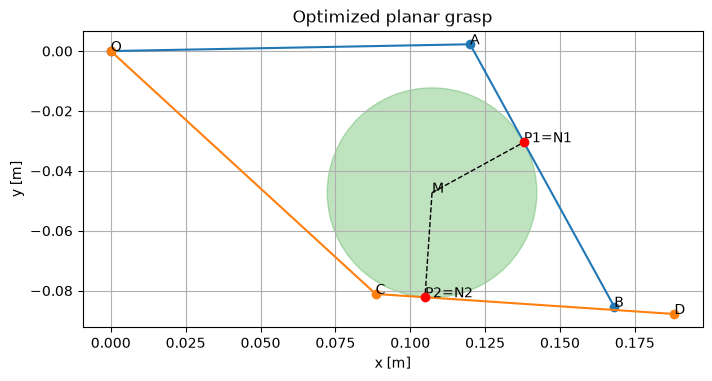

In [9]:
p = points(solution)
fig, ax = plt.subplots(figsize=(8,6))
for ids, color in [([0,1,2],'tab:blue'), ([0,3,4],'tab:orange')]:
    ax.plot(p[ids,0],p[ids,1],'-o',color=color)
ax.add_patch(plt.Circle(p[5],radius,color='tab:green',alpha=.3))
for i in [6,7]:
    ax.plot([p[5,0],p[i,0]],[p[5,1],p[i,1]],'k--',lw=1)
for name, xy in zip(['O','A','B','C','D','M','P1=N1','P2=N2'],p[:8]):
    ax.text(*xy,name)
ax.scatter(p[8:,0],p[8:,1],color='red',zorder=5)
ax.set(xlabel='x [m]',ylabel='y [m]',title='Optimized planar grasp',aspect='equal')
ax.grid(True)
plt.show()

## 7. MuJoCo：4 个 hinge、4 根 capsule、竖直圆柱与棋盘地面
连杆中心线在 z=0，圆柱中心 (x,y,0)，高 0.08m；棋盘地面在 z=-0.1m。
这是抓取构型可视化：物体由 mocap 位姿控制，调用 mj_forward 而不积分动力学。
共用安装座的近端碰撞在模型中排除。接触点红色 site 仅用于显示。
MuJoCo 要求 capsule 半径为正，因此把**显示、碰撞、惯量**分开：
显示杆的半径 visual_link_radius 只影响画面，不参与碰撞，也不进入优化。
碰撞使用半径 eta=1e-5 m 的极细 capsule；圆柱碰撞半径取 r-eta，因此
$$d_{\rm tangent}=(r-\eta)+\eta=r.$$
在垂足位于杆内、圆柱侧面接触的平面情形，相切中心线条件与二维模型一致；实际三维接触点与理想点有 eta 量级偏移。
可见圆柱半径仍为 r，关闭其碰撞。显示外观可能有轻微视觉交叠，不代表碰撞穿透。
每根杆质量独立给定为 0.02 kg，平面转动惯量用 m*l²/12；不会因为碰撞半径趋近零而把质量一起缩为零。

In [10]:
import mujoco
visual_link_radius = 0.0015  # 仅供三维显示，与二维公式无关
collision_epsilon = 1e-5  # 三维接触数值近似；不加入二维接触距离
link_mass = 0.02
assert 0 < collision_epsilon < radius and visual_link_radius > 0 and link_mass > 0
def build_xml(state):
    scene_points = points(state)
    fingers = []
    for i, (a,b,color) in enumerate([(lengths[0],lengths[1],'0.15 0.45 0.9 1'),
                                    (lengths[2],lengths[3],'0.95 0.5 0.12 1')]):
        fingers.append(f'''
        <body name="finger{i}_proximal">
          <inertial pos="{a/2} 0 0" mass="{link_mass}" diaginertia="1e-8 {link_mass*a*a/12} {link_mass*a*a/12}"/>
          <joint name="q{i}0" type="hinge" axis="0 0 1" limited="true" range="-3.141593 3.141593"/>
          <geom name="link{i}0" type="capsule" fromto="0 0 0 {a} 0 0" size="{collision_epsilon}" rgba="0 0 0 0"/>
          <geom name="visual_link{i}0" type="capsule" fromto="0 0 0 {a} 0 0" size="{visual_link_radius}" rgba="{color}" contype="0" conaffinity="0"/>
          <site name="{'A' if i==0 else 'C'}" pos="{a} 0 0" size="0.003"/>
          <body name="finger{i}_distal" pos="{a} 0 0">
            <inertial pos="{b/2} 0 0" mass="{link_mass}" diaginertia="1e-8 {link_mass*b*b/12} {link_mass*b*b/12}"/>
            <joint name="q{i}1" type="hinge" axis="0 0 1" limited="true" range="-3.141593 3.141593"/>
            <geom name="link{i}1" type="capsule" fromto="0 0 0 {b} 0 0" size="{collision_epsilon}" rgba="0 0 0 0"/>
            <geom name="visual_link{i}1" type="capsule" fromto="0 0 0 {b} 0 0" size="{visual_link_radius}" rgba="{color}" contype="0" conaffinity="0"/>
            <site name="{'B' if i==0 else 'D'}" pos="{b} 0 0" size="0.003"/>
          </body>
        </body>''')
    sites = ''.join(f'<body name="marker{i+1}" mocap="true" pos="{v[0]} {v[1]} 0"><site name="P{i+1}" size="0.0025" rgba="1 0 0 1"/></body>' for i,v in enumerate(scene_points[8:]))
    return f'''<mujoco model="planar_2R_grasp">
      <compiler angle="radian"/>
      <option gravity="0 0 -9.81"/>
      <visual><global offwidth="1000" offheight="750"/></visual>
      <default><geom density="1000" friction="{mu} 0.005 0.0001"/><joint damping="1"/></default>
      <asset>
        <texture name="checker" type="2d" builtin="checker" rgb1="0.85 0.85 0.85" rgb2="0.25 0.3 0.35" width="512" height="512"/>
        <material name="floor_mat" texture="checker" texrepeat="12 12" texuniform="true"/>
      </asset>
      <worldbody>
        <light pos="0 -0.4 1" dir="0 0 -1"/>
        <geom name="floor" type="plane" pos="0 0 -0.1" size="1 1 0.01" material="floor_mat"/>
        {''.join(fingers)}
        <body name="object" mocap="true" pos="{state[4]} {state[5]} 0">
          <geom name="cylinder" type="cylinder" size="{radius-collision_epsilon} 0.04" rgba="0 0 0 0"/>
          <geom name="visual_cylinder" type="cylinder" size="{radius} 0.04" rgba="0.2 0.75 0.4 0.75" contype="0" conaffinity="0"/>
        </body>
        {sites}
      </worldbody>
      <contact><exclude body1="finger0_proximal" body2="finger1_proximal"/></contact>
      <actuator>
        <motor name="motor00" joint="q00" gear="1" ctrllimited="true" ctrlrange="-1 1"/>
        <motor name="motor01" joint="q01" gear="1" ctrllimited="true" ctrlrange="-1 1"/>
        <motor name="motor10" joint="q10" gear="1" ctrllimited="true" ctrlrange="-1 1"/>
        <motor name="motor11" joint="q11" gear="1" ctrllimited="true" ctrlrange="-1 1"/>
      </actuator>
      <keyframe><key name="grasp" qpos="{' '.join(map(str,state[:4]))}"/></keyframe>
    </mujoco>'''

xml = build_xml(solution)
output_dir = Path('grasping_output')
output_dir.mkdir(exist_ok=True)
(output_dir/'planar_grasp.xml').write_text(xml,encoding='utf-8')
np.savez(output_dir/'solution.npz',solution=solution,lengths=lengths,r=radius,mu=mu,zero_thickness=True)
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
mujoco.mj_resetDataKeyframe(model,data,0)
mujoco.mj_forward(model,data)
# 确认 MuJoCo 的相对 hinge 角定义与 SymPy FK 一致。
for name, idx in [('A',1),('B',2),('C',3),('D',4)]:
    np.testing.assert_allclose(data.site(name).xpos, np.r_[p[idx],0.], atol=1e-10)
print('MuJoCo FK 与 SymPy 一致，XML 已写入', output_dir)

MuJoCo FK 与 SymPy 一致，XML 已写入 grasping_output


## 8. notebook 内直接显示 MuJoCo 渲染
Renderer 需要可用的 OpenGL 环境；若无图形环境，优化与 XML 导出仍可单独运行。

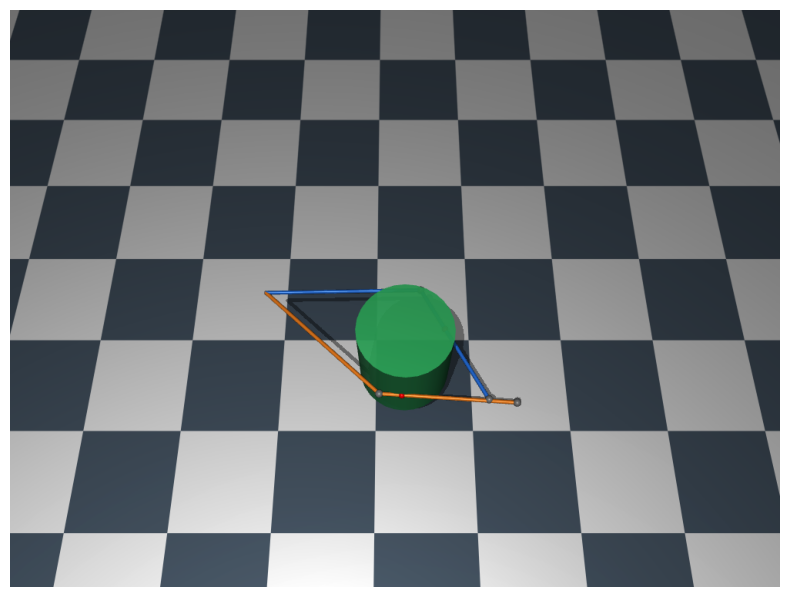

In [11]:
camera = mujoco.MjvCamera()
camera.lookat[:] = [0.10,0,-0.01]
camera.distance, camera.azimuth, camera.elevation = 0.55, 90, -65
with mujoco.Renderer(model,height=750,width=1000) as renderer:
    renderer.update_scene(data,camera=camera)
    rendered = renderer.render().copy()
plt.imsave(output_dir/'mujoco_grasp.png',rendered)
fig, ax = plt.subplots(figsize=(10,7.5))
ax.imshow(rendered)
ax.axis('off')
plt.show()

## 9. 教学图：投影、摩擦锥、优化迭代
左图比较初始姿态（虚线）和求解结果（实线），并标注两个关节的相对角。
中图把接触局部放大：零厚度时 P=N；箭头是内法向，阴影是摩擦锥。
右图显示 cost 和最大约束违反量；二者不一定每一步都下降。
$$V=\max_j\max(0,-g_j).$$
曲线中的 J_scaled 无量纲；另外报告 gap 检查接触，V=0 并不代表 gap=0。
为了让不可行初值也能画图，初值图仅画连杆和圆，不把其投影标作真实接触。

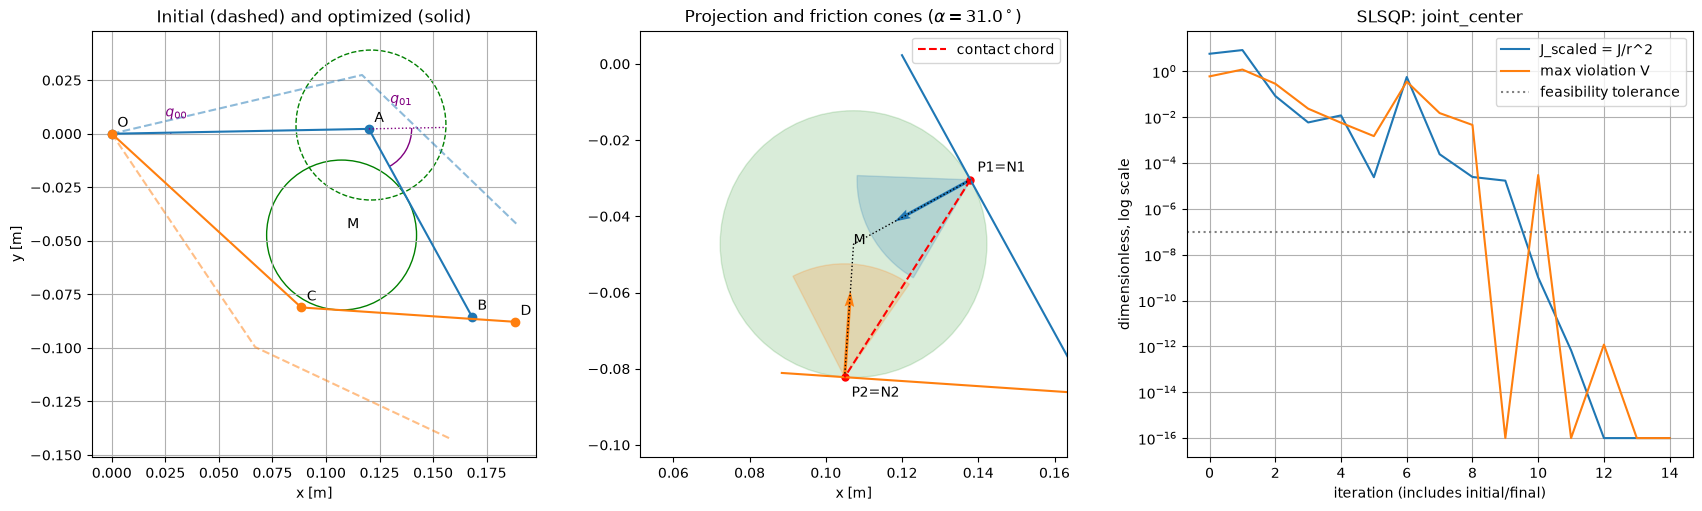

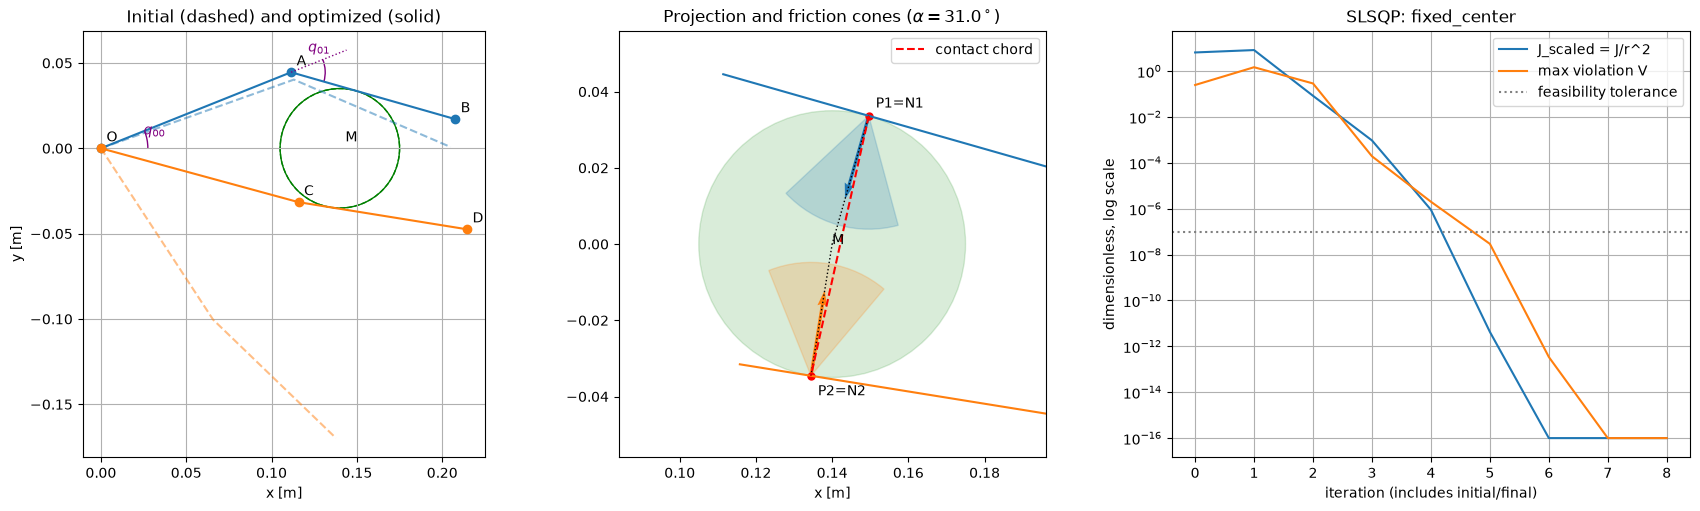

In [12]:
from matplotlib.patches import Arc, Wedge

def teaching_plot(result):
    final = points(result.state)
    initial = points(result.history[0])
    fig, axes = plt.subplots(1,3,figsize=(17,5),constrained_layout=True)
    ax = axes[0]
    for ids, color in [([0,1,2],'tab:blue'),([0,3,4],'tab:orange')]:
        ax.plot(initial[ids,0],initial[ids,1],'--',color=color,alpha=.5)
        ax.plot(final[ids,0],final[ids,1],'-o',color=color)
    for pts, style in [(initial,'--'),(final,'-')]:
        ax.add_patch(plt.Circle(pts[5],radius,fill=False,ls=style,color='green'))
    for name, xy in zip(['O','A','B','C','D','M'],final[:6]):
        ax.annotate(name,xy,xytext=(4,5),textcoords='offset points')
    a0,a1 = np.rad2deg(result.state[:2])
    ax.add_patch(Arc(final[0],.055,.055,theta1=min(0,a0),theta2=max(0,a0),color='purple'))
    ax.text(.025,.008,r'$q_{00}$',color='purple')
    ax.add_patch(Arc(final[1],.04,.04,theta1=min(a0,a0+a1),theta2=max(a0,a0+a1),color='purple'))
    reference_end = final[1] + .035*np.array([np.cos(result.state[0]),np.sin(result.state[0])])
    ax.plot([final[1,0],reference_end[0]],[final[1,1],reference_end[1]],':',color='purple',lw=1)
    ax.text(*(final[1]+[.01,.012]),r'$q_{01}$',color='purple')
    ax.set(title='Initial (dashed) and optimized (solid)',aspect='equal',xlabel='x [m]',ylabel='y [m]')
    ax.grid(True)
    ax = axes[1]
    ax.add_patch(plt.Circle(final[5],radius,color='green',alpha=.15))
    alpha = np.rad2deg(np.arctan(mu))
    for k, color in [(0,'tab:blue'),(1,'tab:orange')]:
        ni, pi = final[6+k], final[8+k]
        a,b = final[[1,2] if k==0 else [3,4]]
        ax.plot([a[0],b[0]],[a[1],b[1]],color=color)
        ax.plot([ni[0],final[5,0]],[ni[1],final[5,1]],'k:',lw=1)
        normal = (final[5]-ni)/np.linalg.norm(final[5]-ni)
        angle = np.rad2deg(np.arctan2(normal[1],normal[0]))
        ax.add_patch(Wedge(pi,radius*.85,angle-alpha,angle+alpha,color=color,alpha=.2))
        ax.quiver(*pi,*(normal*radius*.65),angles='xy',scale_units='xy',scale=1,color=color)
        ax.scatter(*pi,color='red',s=25)
        ax.annotate(f'P{k+1}=N{k+1}',ni,xytext=(5,6 if k==0 else -14),textcoords='offset points')
    ax.plot(final[8:,0],final[8:,1],'r--',label='contact chord')
    ax.text(*final[5],'M')
    ax.set(xlim=(final[5,0]-1.6*radius,final[5,0]+1.6*radius),
           ylim=(final[5,1]-1.6*radius,final[5,1]+1.6*radius),aspect='equal',
           title=fr'Projection and friction cones ($\alpha={alpha:.1f}^\circ$)',xlabel='x [m]')
    ax.legend()
    ax = axes[2]
    violations = [max(0.,-ineq) for gap,ineq in map(residuals,result.history)]
    ax.semilogy(np.maximum([cost(v) for v in result.history],1e-16),label='J_scaled = J/r^2')
    ax.semilogy(np.maximum(violations,1e-16),label='max violation V')
    ax.axhline(1e-7,color='gray',ls=':',label='feasibility tolerance')
    ax.set(title=f'SLSQP: {result.mode}',xlabel='iteration (includes initial/final)',ylabel='dimensionless, log scale')
    ax.legend()
    ax.grid(True)
    return fig

teaching_plot(best)
plt.show()
teaching_plot(fixed_result)
plt.show()

## 10. 非阻塞 passive viewer：打开一次，重复更新
`launch_passive` 会立即返回；不要在 notebook 主线程写无限 `while`，否则后续 cell 无法运行。
更新顺序为：写四个 qpos → 写圆柱及红色标记的 mocap 位置 → `mj_forward` → `viewer.sync()`。
物体用 mocap 是为了直接设置几何位姿，不增加优化变量，不求解动力学。
模型和数据由下面的 session 持有；改初值不重建模型，窗口和相机视角均保留。
修改杆长、半径等模型参数时，应先关闭窗口，再从参数 cell 开始重新运行。
失败时保留上一次显示的可行构型，只报告失败信息。
API 参考：[SciPy SLSQP](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html)、
[MuJoCo Python](https://mujoco.readthedocs.io/en/stable/python.html)。

In [13]:
from contextlib import nullcontext
import mujoco.viewer

class GraspSession:
    def __init__(self, initial_solution):
        self.model = mujoco.MjModel.from_xml_string(build_xml(initial_solution))
        self.data = mujoco.MjData(self.model)
        self.viewer = None
        self.current = np.asarray(initial_solution).copy()
        self.update(self.current)

    def open(self):
        if self.viewer is not None and self.viewer.is_running():
            return
        self.viewer = mujoco.viewer.launch_passive(self.model,self.data)
        with self.viewer.lock():
            self.viewer.cam.lookat[:] = [0.10,0,-0.01]
            self.viewer.cam.distance = .55
            self.viewer.cam.azimuth = 90
            self.viewer.cam.elevation = -65
        self.viewer.sync()

    def update(self, zz):
        # 只有通过优化残差检查的解才能作为新的抓取显示。
        zz = np.asarray(zz,dtype=float)
        if zz.shape != (6,) or not np.all(np.isfinite(zz)):
            raise ValueError('求解结果格式错误。')
        gap, iq = residuals(zz)
        limits = np.asarray(bounds)
        if gap >= contact_tol or iq < -constraint_tol or np.any(zz < limits[:,0]-constraint_tol) or np.any(zz > limits[:,1]+constraint_tol):
            raise ValueError('结果不可行，保持原显示。')
        pts = points(zz)
        live = self.viewer is not None and self.viewer.is_running()
        with self.viewer.lock() if live else nullcontext():
            for name,value in zip(['q00','q01','q10','q11'],zz[:4]):
                self.data.qpos[self.model.joint(name).qposadr[0]] = value
            for name,xy in [('object',zz[4:]),('marker1',pts[8]),('marker2',pts[9])]:
                mid = self.model.body(name).mocapid[0]
                self.data.mocap_pos[mid] = [*xy,0.]
                self.data.mocap_quat[mid] = [1,0,0,0]
            self.data.qvel[:] = 0
            self.data.ctrl[:] = 0
            self.data.qfrc_applied[:] = 0
            mujoco.mj_forward(self.model,self.data)
            self.current = zz.copy()
        # sync 自身取得 viewer 的锁，故放在 lock() 外面。
        if live:
            self.viewer.sync()

    def close(self):
        if self.viewer is not None:
            self.viewer.close()
            self.viewer = None

# 重跑本 cell 时先关闭旧窗口，避免窗口泄漏。
if 'session' in globals():
    session.close()
session = GraspSession(solution)

def resolve_and_update(initial, n_starts=1, show_plot=True, mode='joint_center', center=None):
    global solution, best, p
    runs, accepted = solve_grasp(initial,n_starts=n_starts,mode=mode,center=center)
    if not accepted:
        for res in runs:
            print(res.message, 'max |gap| [m] / min ineq =', residuals(res.state))
        print('本次未得到可行解，viewer 保持上次成功结果。')
        return None
    chosen = min(accepted,key=lambda res: res.fun)
    session.update(chosen.state)
    solution, best, p = chosen.state.copy(), chosen, points(chosen.state)
    print('q [deg] =', np.round(np.rad2deg(solution[:4]),5))
    print('mode =',mode,'SLSQP 变量数 =',len(chosen.x))
    print('M [m] =', solution[4:], 'J [m²] =', chosen.contact_cost, 'J_scaled =',chosen.fun)
    print('两侧间隙 [m] =',contact_gaps(solution))
    print('max |gap| [m] / min ineq =', residuals(solution))
    (output_dir/'planar_grasp.xml').write_text(build_xml(solution),encoding='utf-8')
    np.savez(output_dir/'solution.npz',solution=solution,lengths=lengths,r=radius,mu=mu,zero_thickness=True)
    if show_plot:
        teaching_plot(chosen)
        plt.show()
    return chosen

### 操作 A：打开窗口（运行后立刻可以继续执行下一个 cell）
鼠标操作由 viewer 自己的线程处理。窗口关闭后，可以重跑本 cell 再打开。
本 cell 标记为 interactive，自动无界面验证时跳过；课堂中直接执行即可。

In [ ]:
session.open()

### 操作 B：修改下面的初值，然后反复运行本 cell
角度输入用“度”方便教学，在调用优化器前转成弧度。x、y 输入单位为 m。
设置 mode='joint_center' 同时优化圆心与关节；mode='fixed_center' 只优化关节。
联合模式下 xy_init 是搜索起点；固定模式下 center_given 是硬给定的物体位置，xy_init 不参与求解。
试试 [50,-60,-25,30] 与 [25,-15,-50,60]，观察接近零 cost 的多组解。
`n_starts=1` 展示输入初值自身的效果，改成 12 则启用附近扰动多初值搜索。
请先运行操作 A 打开窗口。即使没打开窗口，这个 cell 也能求解并绘图。

q [deg] = [ 42.72349 -62.33724 -16.31136  33.94489]
mode = joint_center SLSQP 变量数 = 6
M [m] = [0.1620543  0.01792556] J [m²] = 6.98149604840373e-33 J_scaled = 5.699180447676515e-30
两侧间隙 [m] = [-5.55111512e-17  6.24500451e-17]
max |gap| [m] / min ineq = (np.float64(6.245004513516506e-17), np.float64(-4.440892098500626e-16))


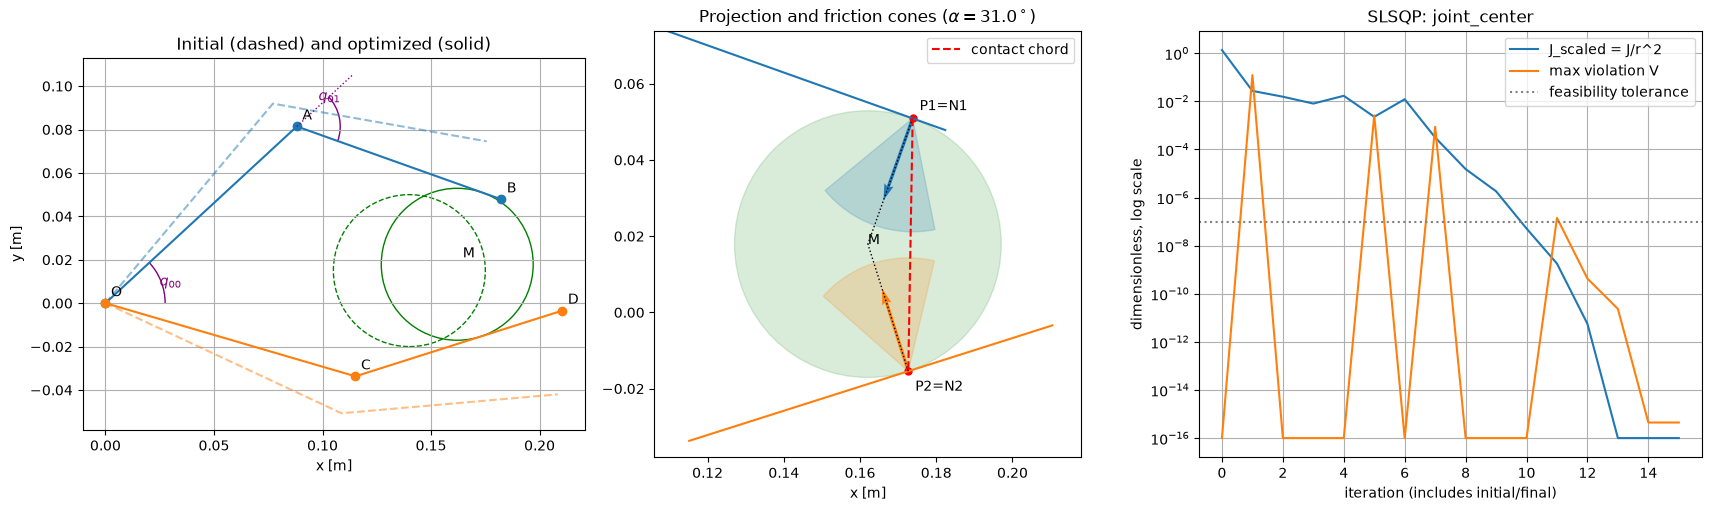

In [14]:
q_init_deg = [50., -60., -25., 30.]
xy_init = [0.14, 0.015]
mode = 'joint_center'  # 或 'fixed_center'
center_given = [0.14, 0.0]
if mode == 'joint_center':
    initial_guess = np.r_[np.deg2rad(q_init_deg), xy_init]
    new_result = resolve_and_update(initial_guess,n_starts=1,mode=mode)
elif mode == 'fixed_center':
    new_result = resolve_and_update(np.deg2rad(q_init_deg),n_starts=1,mode=mode,center=center_given)
else:
    raise ValueError('未知求解模式。')

### 操作 C：结束演示时关闭窗口
执行 `session.close()` 即可；此处保持注释，让 Run All 之后窗口仍然保留。
课堂思考：1. 删除垂足范围约束会发生什么？2. 增大 mu，摩擦锥如何变化？
3. 固定圆心与仅给定圆心初值有何不同？4. 为什么 cost 接近零仍不能保证解唯一？

In [15]:
# session.close()

## 11. 接触点的速度 Jacobian 与夹持力矩
以下进入动力学：四个 hinge 分别由 gear=1 的 motor 驱动，`data.ctrl` 的单位为 N·m。
**不再逐帧覆盖 qpos，而是计算力矩后执行 mj_step。** 圆柱仍由 mocap 固定，适合观察夹持反力；
固定支撑会承受剩余载荷，这不是自由物体的搬运或三维稳定性实验。

对附着在第 i 个远端连杆上的接触点，世界坐标速度满足
$$\dot p_i=J_i(q)\dot q,\qquad J_i\in\mathbb R^{3\times4}.$$
平面机构只使用前两行：$J_{i,xy}\in\mathbb R^{2\times4}$；第一指后两列、第二指前两列为零。
零厚度时接触材料点为 $P_1=N_1=A+a_0e(\theta_1)$，其中 $a_0=t_1l_{01}$。
求材料点 Jacobian 时，**先确定 a0，再保持 a0 不变求导**，不能对移动投影参数 t1 求导。
$$J_{1,xy}=\begin{bmatrix}-P_{1y}&-(P_{1y}-A_y)&0&0\\P_{1x}&P_{1x}-A_x&0&0\end{bmatrix}.$$
第二指对应的非零列为最后两列，将 A 换成 C、P1 换成 P2 即可。
所以第一指的附加力矩直接简化为平面力矩：
$$\tau_{00}=P_{1x}f_{1y}-P_{1y}f_{1x},\qquad
\tau_{01}=(P_{1x}-A_x)f_{1y}-(P_{1y}-A_y)f_{1x}.$$
这里无需考虑接触点相对杆中心线的厚度偏移。
MuJoCo 的 `mj_jac(model,data,jacp,jacr,point_world,body_id)` 可以在指定连杆的任意世界坐标点求 Jacobian。
**不能使用红色 P1/P2 的 mj_jacSite**：它们是独立 mocap 标记，不属于手指，Jacobian 为零。
也不能直接对优化中的移动垂足/候选点 P(q,M) 求导作为受力 Jacobian：接触力作用于连杆材料点。
本例先把优化接触点转换到远端连杆局部坐标；仿真时有实际接触就使用 `data.contact.pos`，
尚未接触则使用随连杆运动的材料点。每次调用 mj_jac 都明确指定远端连杆 body。

**力的正方向：** $f_i$ 表示手指希望施加给物体的力，物体对手指的反力是 $-f_i$。
这里 F 是**每一侧**的力大小（N），不是两侧力大小之和。使用接触点连线，
$$\hat d=\frac{P_2-P_1}{\|P_2-P_1\|},\quad f_1=F\hat d,\quad f_2=-F\hat d.$$
两力等大、反向、共线，在理想接触处合力与合力矩均为零；优化中的摩擦锥约束确保方向可行。
由虚功 $\tau^T\delta q=f^T\delta p$ 得到
$$\boxed{\tau_{\rm grip}=J_1^Tf_1+J_2^Tf_2\in\mathbb R^4.}$$
这是抵抗物体反力所需的**附加驱动力矩**。若 F 表示“物体施加给手指的外力”，补偿符号应反过来。

In [16]:
JOINT_NAMES = ['q00','q01','q10','q11']
DISTAL_NAMES = ['finger0_distal','finger1_distal']

a_contact0,a_contact1 = sp.symbols('a_0 a_1',real=True)
material_P1 = A+a_contact0*e(theta1)
material_P2 = C+a_contact1*e(theta2)
J1_planar_expr = material_P1.jacobian(z[:4])
J2_planar_expr = material_P2.jacobian(z[:4])
print('零厚度杆接触 Jacobian，a_0、a_1 为固定材料坐标：')
sp.pprint(J1_planar_expr)
sp.pprint(J2_planar_expr)
display(J1_planar_expr,J2_planar_expr)
planar_contact_jacobian = sp.lambdify([z[:4],a_contact0,a_contact1],
    [J1_planar_expr.subs(params),J2_planar_expr.subs(params)],'numpy',cse=True)

def contact_anchors(m, d, state):
    """在目标构型建立固定在各远端连杆上的材料点，返回局部坐标。"""
    nominal = mujoco.MjData(m)
    nominal.qpos[:] = state[:4]
    mujoco.mj_forward(m,nominal)
    anchors = []
    for name,xy in zip(DISTAL_NAMES,points(state)[6:8]):
        body = nominal.body(name)
        anchors.append(body.xmat.reshape(3,3).T @ (np.r_[xy,0.]-body.xpos))
    return np.asarray(anchors)

def contact_jacobians(m,d,anchors,use_actual_contacts=True):
    """输入 data 必须已 mj_forward；返回两个 3×nv Jacobian、世界坐标点、接触 ID。"""
    jacobians, locations, ids = [], [], []
    cylinder = m.geom('cylinder').id
    for i,name in enumerate(DISTAL_NAMES):
        body_id = m.body(name).id
        body = d.body(name)
        position = body.xpos + body.xmat.reshape(3,3) @ anchors[i]
        candidates = []
        if use_actual_contacts:
            link = m.geom(f'link{i}1').id
            candidates = [k for k in range(d.ncon)
                          if set(d.contact[k].geom)=={link,cylinder}]
        cid = min(candidates,key=lambda k: np.linalg.norm(d.contact[k].pos-position)) if candidates else None
        if cid is not None:
            position = d.contact[cid].pos.copy()
        jacp = np.zeros((3,m.nv))
        mujoco.mj_jac(m,d,jacp,None,np.asarray(position),body_id)
        jacobians.append(jacp)
        locations.append(position)
        ids.append(cid)
    return np.asarray(jacobians),np.asarray(locations),ids

def desired_grip_forces(state,F):
    if not np.isfinite(F) or F < 0:
        raise ValueError('F 必须为非负有限数，表示每侧夹持力大小，单位 N。')
    pp = points(state)
    direction = np.r_[pp[9]-pp[8],0.]
    direction /= np.linalg.norm(direction)
    return F*np.array([direction,-direction])

F = 1.0  # 每侧 1 N；修改此值后重跑本节与控制实验
grasp_state = solution.copy()  # 使用最近一次优化成功的六维结果
anchors = contact_anchors(session.model,session.data,grasp_state)
nominal_data = mujoco.MjData(session.model)
nominal_data.qpos[:] = grasp_state[:4]
mujoco.mj_forward(session.model,nominal_data)
J_contact, P_world, _ = contact_jacobians(session.model,nominal_data,anchors,use_actual_contacts=False)
# 对照简化的零厚度材料点公式；这里用理想接触点，非三维 epsilon 偏移后的碰撞点。
pp = points(grasp_state)
a_values = [np.linalg.norm(pp[6]-pp[1]),np.linalg.norm(pp[7]-pp[3])]
J_planar = np.asarray(planar_contact_jacobian(grasp_state[:4],*a_values),dtype=float)
np.testing.assert_allclose(J_contact[:,:2,:],J_planar,atol=1e-10)
F_world = desired_grip_forces(grasp_state,F)
tau_each = np.array([J.T @ force for J,force in zip(J_contact,F_world)])
tau_grip = tau_each.sum(axis=0)
for i in range(2):
    print(f'J{i+1}_xy [m/rad] =\n',J_contact[i,:2])
    print(f'f{i+1}_world [N] =',F_world[i])
    print(f'J{i+1}.T @ f{i+1} [N m] =',tau_each[i])
print('附加关节力矩 [q00,q01,q10,q11] [N m] =',tau_grip)

零厚度杆接触 Jacobian，a_0、a_1 为固定材料坐标：
⎡-a₀⋅sin(q₀₀ + q₀₁) - l₀₀⋅sin(q₀₀)  -a₀⋅sin(q₀₀ + q₀₁)  0  0⎤
⎢                                                           ⎥
⎣a₀⋅cos(q₀₀ + q₀₁) + l₀₀⋅cos(q₀₀)   a₀⋅cos(q₀₀ + q₀₁)   0  0⎦
⎡0  0  -a₁⋅sin(q₁₀ + q₁₁) - l₁₀⋅sin(q₁₀)  -a₁⋅sin(q₁₀ + q₁₁)⎤
⎢                                                           ⎥
⎣0  0  a₁⋅cos(q₁₀ + q₁₁) + l₁₀⋅cos(q₁₀)   a₁⋅cos(q₁₀ + q₁₁) ⎦


Matrix([
[-a_0*sin(q_00 + q_01) - l_00*sin(q_00), -a_0*sin(q_00 + q_01), 0, 0],
[ a_0*cos(q_00 + q_01) + l_00*cos(q_00),  a_0*cos(q_00 + q_01), 0, 0]])

Matrix([
[0, 0, -a_1*sin(q_10 + q_11) - l_10*sin(q_10), -a_1*sin(q_10 + q_11)],
[0, 0,  a_1*cos(q_10 + q_11) + l_10*cos(q_10),  a_1*cos(q_10 + q_11)]])

J1_xy [m/rad] =
 [[-0.05089475  0.03052056  0.          0.        ]
 [ 0.17380302  0.08564663  0.          0.        ]]
f1_world [N] = [-0.01727983 -0.99985069  0.        ]
J1.T @ f1 [N m] = [-0.17289761 -0.08616124  0.          0.        ]
J2_xy [m/rad] =
 [[ 0.          0.          0.01542992 -0.01827293]
 [ 0.          0.          0.17265677  0.05748681]]
f2_world [N] = [ 0.01727983  0.99985069 -0.        ]
J2.T @ f2 [N m] = [0.         0.         0.17289761 0.05716248]
附加关节力矩 [q00,q01,q10,q11] [N m] = [-0.17289761 -0.08616124  0.17289761  0.05716248]


## 12. 计算力矩法 + PD：从位置误差到四个关节力矩
MuJoCo 的运动方程写为
$$M(q)\ddot q+b(q,\dot q)=\tau+\tau_{\rm passive}+\tau_{\rm contact}.$$
$b$ 包括科里奥利力、离心力和重力，对应 `qfrc_bias`；被动阻尼等对应 `qfrc_passive`。
注意 M(q) 是质量矩阵，与前文圆心 M 的含义不同。
定义 $e=q_d-q$、$\dot e=\dot q_d-\dot q$，先构造期望加速度
$$a_{\rm cmd}=\ddot q_d+K_d\dot e+K_p e,$$
再计算
$$\tau_{\rm track}=M(q)a_{\rm cmd}+b-\tau_{\rm passive},\qquad
\boxed{\tau_{\rm cmd}=\tau_{\rm track}+\tau_{\rm grip}.}$$
无接触且不饱和时得到 $\ddot e+K_d\dot e+K_pe=0$。这里 PD 位于加速度层，
所以 Kp 单位为 s⁻²、Kd 为 s⁻¹，不是直接力矩 PD 的增益。
默认 Kp=40000、Kd=400，对应无接触理想模型的临界阻尼；较高的位置刚度有助于减小受力后的角度偏差。
这些增益用于本例理想刚体仿真，需要结合步长、惯量、执行器上限重新选择，不能直接照搬到硬件。
不能把 `qfrc_constraint` 也整体抵消，否则会主动抵消夹持反力。
本模型 z 轴转动、连杆在水平面，重力对这些关节的力矩通常为零，但代码仍保留完整 bias。

采用五次轨迹 $s(u)=10u^3-15u^4+6u^5$，$u=t/T$，使起终点速度、加速度均为零：
$$q_d(t)=q_0+s(t/T)(q_g-q_0).$$
到达后缓慢增加夹持力。相应连杆进入 10 微米的接触邻域后才施加该侧附加力矩。
若只允许已存在的 MuJoCo contact 触发夹持，位于表面外极小正间隙处的精确跟踪可能永远无法开始加力。
`J^T F` 是力前馈，不是闭环力控制；位置误差、软接触、摩擦和力矩饱和都会影响实际接触力。
因此图中还会显示 MuJoCo 实测法向力，并与 $f_i\cdot n_i$ 比较，而不是直接与 F 比较。
本例固定圆柱并保留真实碰撞；仿真只跟踪附近构型，不包含无碰撞路径规划。

In [17]:
def full_mass_matrix(m,d):
    mass = np.zeros((m.nv,m.nv))
    # MuJoCo 3.10 起的签名为 (model,data,dst)，旧版本为 (model,dst,data.qM)。
    try:
        mujoco.mj_fullM(m,d,mass)
    except TypeError:
        mujoco.mj_fullM(m,mass,d.qM)
    return mass

def quintic_reference(t,q_start,q_goal,T):
    u = np.clip(t/T,0.,1.)
    s = 10*u**3-15*u**4+6*u**5
    sd = (30*u**2-60*u**3+30*u**4)/T if t < T else 0.
    sdd = (60*u-180*u**2+120*u**3)/T**2 if t < T else 0.
    delta = q_goal-q_start
    return q_start+s*delta,sd*delta,sdd*delta

def computed_torque(m,d,q_des,qd_des,qdd_des,kp,kd):
    acceleration = qdd_des + kd*(qd_des-d.qvel) + kp*(q_des-d.qpos)
    return full_mass_matrix(m,d) @ acceleration + d.qfrc_bias-d.qfrc_passive

def measured_normal_forces(m,d):
    """累加同一远端连杆和圆柱之间的法向力，单位 N；不是整段手指的所有碰撞力。"""
    values = np.zeros(2)
    cylinder = m.geom('cylinder').id
    for i in range(2):
        link = m.geom(f'link{i}1').id
        for k in range(d.ncon):
            if set(d.contact[k].geom)=={link,cylinder}:
                wrench = np.zeros(6)
                mujoco.mj_contactForce(m,d,k,wrench)
                values[i] += max(0.,wrench[0])
    return values

def run_torque_control(active_session,state,F=1.0,move_time=1.5,hold_time=2.0,
                       kp=40000.,kd=400.,torque_limit=.8,realtime=False,q_start=None):
    """有限时长动力学实验；模型只有四个 hinge、四个 gear=1 motor，物体保持 mocap 固定。"""
    if move_time <= 0 or hold_time <= 0 or kp <= 0 or kd <= 0 or not 0 < torque_limit <= 1.:
        raise ValueError('时间、增益应为正，torque_limit 应在 (0,1] N m。')
    active_session.update(state)  # 校验抓取，固定物体，仅在初始化时设置 qpos
    m,d = active_session.model,active_session.data
    assert m.nq==m.nv==m.nu==4
    target_q = np.asarray(state[:4]).copy()
    start_q = target_q+np.deg2rad([2.,0.,-2.,0.]) if q_start is None else np.asarray(q_start,dtype=float)
    if start_q.shape != (4,) or not np.all(np.isfinite(start_q)) or np.any(np.abs(start_q)>np.pi):
        raise ValueError('q_start 应为四个 [-pi,pi] 内的关节角，单位 rad。')
    force_target = desired_grip_forces(state,F)
    anchors = contact_anchors(m,d,state)
    live = active_session.viewer is not None and active_session.viewer.is_running()
    handle = active_session.viewer if live else None
    with handle.lock() if handle else nullcontext():
        m.opt.timestep = .0005
        m.opt.integrator = mujoco.mjtIntegrator.mjINT_EULER
        m.dof_damping[:] = .002
        d.qpos[:] = start_q
        d.qvel[:] = 0
        d.ctrl[:] = 0
        d.time = 0
        mujoco.mj_forward(m,d)
    log = {key:[] for key in ['time','q','q_des','tau_track','tau_grip','tau_cmd','normal_force','normal_target','saturated']}
    wall_start = time.perf_counter()
    for step in range(int(np.ceil((move_time+hold_time)/m.opt.timestep))):
        if handle and not handle.is_running():
            break
        with handle.lock() if handle else nullcontext():
            mujoco.mj_forward(m,d)
            t = d.time
            q_des,qd_des,qdd_des = quintic_reference(t,start_q,target_q,move_time)
            tau_track = computed_torque(m,d,q_des,qd_des,qdd_des,kp,kd)
            jacobians,positions,cids = contact_jacobians(m,d,anchors)
            u = np.clip((t-move_time)/.5,0.,1.)
            ramp = 3*u*u-2*u*u*u
            forces = ramp*force_target
            # 接触邻域允许消除优化容差带来的微小正间隙；远离物体时仍只运行位置环。
            center_xy = d.body('object').xpos[:2]
            gaps = [point_segment_distance(center_xy,d.site(a).xpos[:2],d.site(b).xpos[:2])
                    -radius for a,b in [('A','B'),('C','D')]]
            enabled = np.asarray(gaps) <= 1e-5
            tau_grip = sum((J.T @ force)*on for J,force,on in zip(jacobians,forces,enabled))
            tau_raw = tau_track+tau_grip
            d.ctrl[:] = np.clip(tau_raw,-torque_limit,torque_limit)
            # 不再使用 qfrc_applied 叠加同一力矩，避免重复驱动。
            d.qfrc_applied[:] = 0
            # 更新可视化标记的位置；此标记不参与 Jacobian 或受力。
            for i,position in enumerate(positions):
                d.mocap_pos[m.body(f'marker{i+1}').mocapid[0]] = position
            mujoco.mj_forward(m,d)
            if step % 10 == 0:
                center = d.body('object').xpos
                normals = center-positions
                normals /= np.linalg.norm(normals,axis=1)[:,None]
                sample = dict(time=t,q=d.qpos.copy(),q_des=q_des.copy(),tau_track=tau_track.copy(),
                              tau_grip=tau_grip.copy(),tau_cmd=d.ctrl.copy(),
                              normal_force=measured_normal_forces(m,d),
                              normal_target=np.sum(forces*normals,axis=1),
                              saturated=np.any(np.abs(tau_raw)>torque_limit))
                for key,value in sample.items():
                    log[key].append(value)
            mujoco.mj_step(m,d)
        if handle and step % 30 == 0:
            handle.sync()
        if realtime and step % 30 == 0:
            time.sleep(max(0.,d.time-(time.perf_counter()-wall_start)))
    with handle.lock() if handle and handle.is_running() else nullcontext():
        mujoco.mj_forward(m,d)
    if handle and handle.is_running():
        handle.sync()
    result = {key:np.asarray(value) for key,value in log.items()}
    result['final_q'] = d.qpos.copy()
    result['goal_q'] = target_q
    print('最终角误差 [deg] =',np.rad2deg(target_q-d.qpos))
    print('力矩饱和采样数 =',int(np.sum(result['saturated'])))
    print('末次记录的附加力矩 [N m] =',result['tau_grip'][-1])
    print('末次法向力 实测/期望 [N] =',result['normal_force'][-1],result['normal_target'][-1])
    return result

## 13. 两个对照实验：先验证轨迹跟踪，再叠加夹持力
两次从相同的附近姿态起步：第一组 F=0，第二组在到达后把夹持力逐渐升到 F。
自动实验使用独立 session，不影响前面已打开的窗口；后面的操作 D 将在原 passive viewer 中实时运行。

最终角误差 [deg] = [-3.18055468e-14 -6.36110936e-14  1.59027734e-14  3.18055468e-14]
力矩饱和采样数 = 0
末次记录的附加力矩 [N m] = [0. 0. 0. 0.]
末次法向力 实测/期望 [N] = [0. 0.] [0. 0.]


最终角误差 [deg] = [ 0.1406845  -0.19729455 -0.12910724  0.29689951]
力矩饱和采样数 = 0
末次记录的附加力矩 [N m] = [-0.17291909 -0.08597936  0.17277492  0.05696863]
末次法向力 实测/期望 [N] = [0.91731617 0.92993768] [0.94732533 0.94870789]


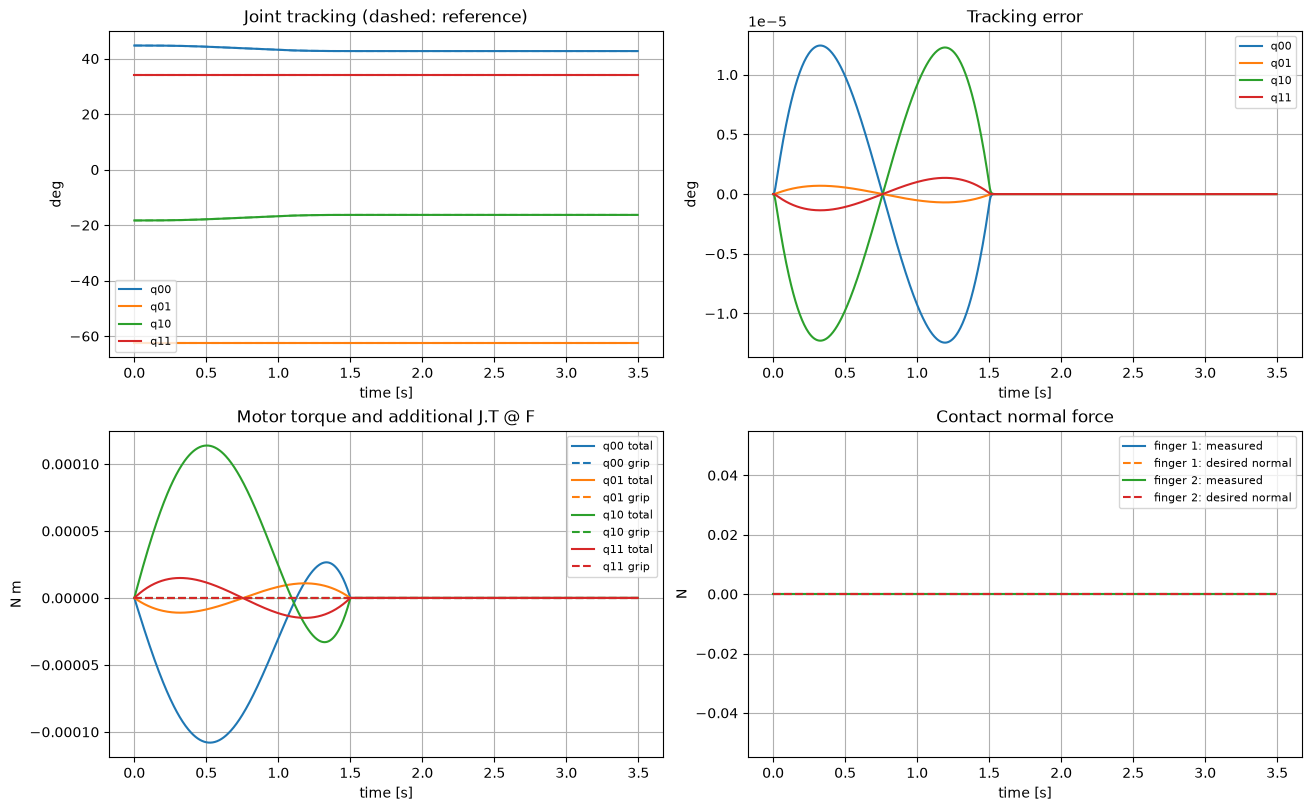

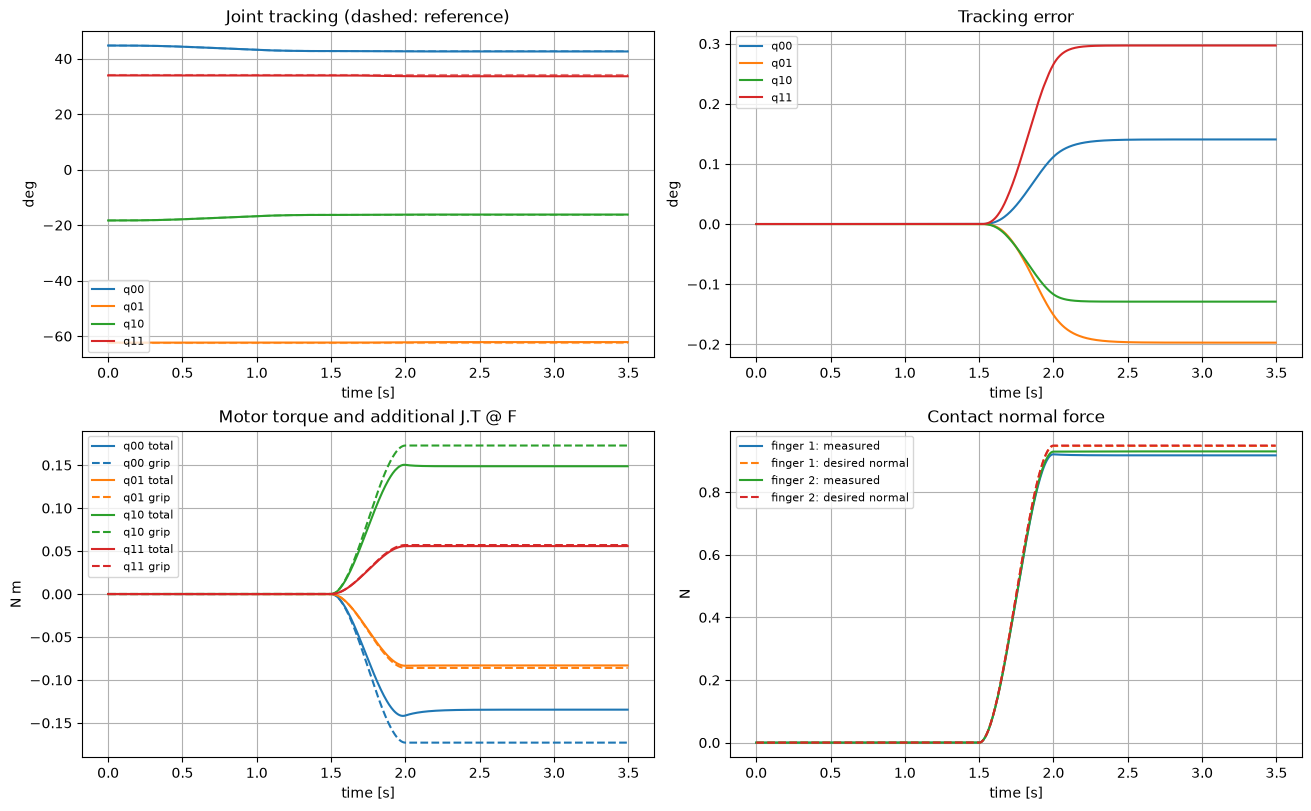

In [18]:
control_session = GraspSession(grasp_state)
tracking_log = run_torque_control(control_session,grasp_state,F=0.)
gripping_log = run_torque_control(control_session,grasp_state,F=F)

def plot_control(log):
    fig,axes = plt.subplots(2,2,figsize=(13,8),constrained_layout=True)
    t = log['time']
    for i,name in enumerate(JOINT_NAMES):
        color = f'C{i}'
        axes[0,0].plot(t,np.rad2deg(log['q'][:,i]),color=color,label=name)
        axes[0,0].plot(t,np.rad2deg(log['q_des'][:,i]),'--',color=color,alpha=.6)
        axes[0,1].plot(t,np.rad2deg(log['q_des'][:,i]-log['q'][:,i]),label=name)
        axes[1,0].plot(t,log['tau_cmd'][:,i],color=color,label=name+' total')
        axes[1,0].plot(t,log['tau_grip'][:,i],'--',color=color,label=name+' grip')
    for i in range(2):
        axes[1,1].plot(t,log['normal_force'][:,i],label=f'finger {i+1}: measured')
        axes[1,1].plot(t,log['normal_target'][:,i],'--',label=f'finger {i+1}: desired normal')
    for ax,title,units in zip(axes.flat,['Joint tracking (dashed: reference)','Tracking error',
                                        'Motor torque and additional J.T @ F','Contact normal force'],
                              ['deg','deg','N m','N']):
        ax.set(title=title,xlabel='time [s]',ylabel=units)
        ax.grid(True)
        ax.legend(fontsize=8)
    return fig

plot_control(tracking_log).savefig(output_dir/'torque_tracking.png',dpi=140)
plt.show()
plot_control(gripping_log).savefig(output_dir/'torque_gripping.png',dpi=140)
plt.show()
np.savez(output_dir/'torque_control_log.npz',**gripping_log)

### 操作 D：在 passive viewer 中运行力矩控制
此 cell 默认演示 3.5 秒，完成后返回，可以改 F 或优化结果后反复运行。
运行期间使用 mj_step 推进真实动力学；窗口在结束后停留在最后一帧，不再后台积分。
前面“操作 B”重新优化后，重跑第 11 节可打印新构型的 Jacobian/附加力矩；
操作 D 会直接读取最新 solution。需要保持持续闭环时，可增加 hold_time。
官方接口参考：[mj_jac / mj_fullM / mj_contactForce](https://mujoco.readthedocs.io/en/stable/APIreference/APIfunctions.html)。

In [ ]:
session.open()
live_control_log = run_torque_control(session,solution,F=F,realtime=True)
plot_control(live_control_log)
plt.show()

课堂思考：1. 为什么固定在 mocap 上的红点 Jacobian 为零？2. 把 F 加倍，附加力矩是否也加倍？
3. 为什么接触后跟踪误差不再严格满足无接触时的二阶方程？4. 为什么纯 J^T F 前馈不保证实测力等于设定值？
5. 若四个电机的力矩上限不足，会怎样影响位置和夹持力？